In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import gurobipy as gp
from gurobipy import GRB

In [9]:
#Problem Parameters
n = 100 #Number of items 
d = 1 #Number of Features

#Random Inputs
A = np.random.randn(n, d)
x = np.random.randn(d)

#Problem Inputs
weight = np.random.randn(n) + 4
value = A @ x + 4
capacity = np.mean(value) * n / 2

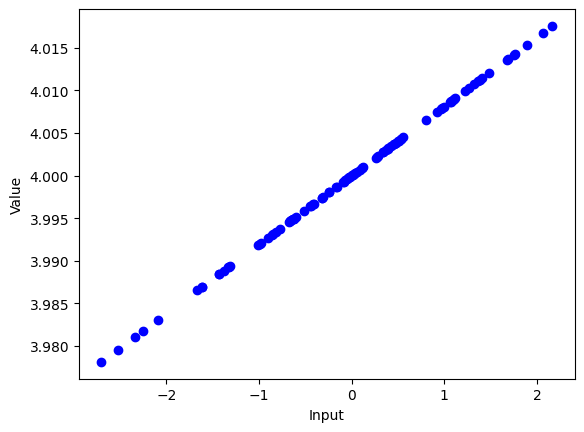

In [3]:
# Create the scatter plot
plt.scatter(A.squeeze(), value, color='blue', marker='o')

# Add labels and title
plt.xlabel('Input')
plt.ylabel('Value')

# Display the plot
plt.show()

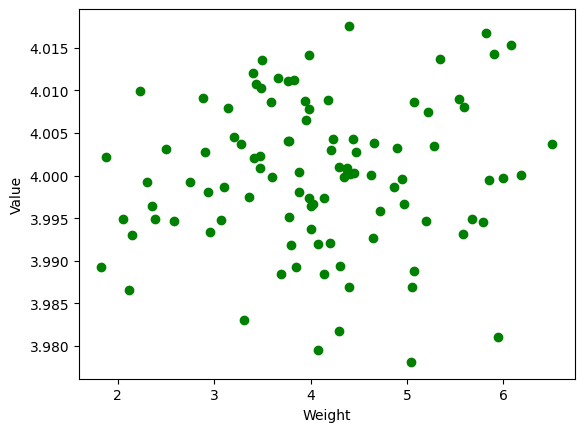

In [4]:
# Create the scatter plot
plt.scatter(weight, value, color='green', marker='o')

# Add labels and title
plt.xlabel('Weight')
plt.ylabel('Value')

# Display the plot
plt.show()

In [12]:
#Create the Model
model = gp.Model("knapsack")

#Add Decision Variables
x = model.addMVar(shape=n, vtype=GRB.BINARY, name="x")

#Set Objective
model.setObjective(value @ x, GRB.MAXIMIZE)

#Add Constraints
model.addConstr(weight @ x <= capacity)

#Optimize
model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i9-8950HK CPU @ 2.90GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1 rows, 100 columns and 100 nonzeros (Max)
Model fingerprint: 0x4759b3a4
Model has 100 linear objective coefficients
Variable types: 0 continuous, 100 integer (100 binary)
Coefficient statistics:
  Matrix range     [2e+00, 8e+00]
  Objective range  [3e+00, 5e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+02, 2e+02]

Found heuristic solution: objective 189.6979808
Presolve time: 0.00s
Presolved: 1 rows, 100 columns, 100 nonzeros
Variable types: 0 continuous, 100 integer (100 binary)

Root relaxation: objective 2.331504e+02, 1 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/